# XGBoost Pipeline — Trajectory Prediction Metrics (GAM-Style)

This notebook fits an XGBoost regressor to trajectory prediction error metrics using prepared trajectory/scene characteristics.
It mirrors the structure of `gam.ipynb`, uses a random train/validation/test split, and focuses interpretability on conditions where performance is poor vs. well.

## 1. Imports and Configuration

In [1]:
# Core libraries
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import PartialDependenceDisplay

import xgboost as xgb
import optuna
import shap

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Notebook-level config constants
DATA_PATH = Path('../../results/interpretable_model/prepared_data/prepared_data_ml_ade.csv')
TARGET_COL = None  # Optional override, e.g. 'ml_ade_log'

RANDOM_STATE = 42
k_outer_fold = 5
k_inner_fold = 3
N_OPTUNA_TRIALS = 40
MAX_BOOST_ROUNDS = 2000
EARLY_STOPPING_ROUNDS = 50
N_JOBS = -1
POOR_WELL_QUANTILE = 0.20

SAVE_DIR = Path('../../results/interpretable_model/xgboost')
PLOTS_DIR = SAVE_DIR / 'plots'
TABLES_DIR = SAVE_DIR / 'tables'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print('Imports and configuration loaded.')
print(f'DATA_PATH: {DATA_PATH}')
print(f'SAVE_DIR:  {SAVE_DIR.resolve()}')
print(
    'Nested CV: '
    f'outer={k_outer_fold}, inner={k_inner_fold}, optuna_trials={N_OPTUNA_TRIALS}, '
    f'early_stop={EARLY_STOPPING_ROUNDS}'
)


Imports and configuration loaded.
DATA_PATH: ../../results/interpretable_model/prepared_data/prepared_data_ml_ade.csv
SAVE_DIR:  /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/xgboost
Nested CV: outer=5, inner=3, bayes_iter=40


## 2. Load Prepared Data and Inspect

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape}')
print('Columns:')
print(df.columns.tolist())

display(df.head())

missing_summary = df.isna().sum().sort_values(ascending=False)
print('\nMissing values per column:')
display(missing_summary.to_frame('missing_count'))

dtype_summary = df.dtypes.astype(str).to_frame('dtype')
print('\nColumn dtypes:')
display(dtype_summary)

Dataset shape: (451, 14)
Columns:
['max_speed', 'std_speed', 'mean_acceleration', 'max_acceleration', 'path_efficiency', 'heading_change', 'has_collision', 'min_neighbor_distance', 'scene_num_agents', 'scene_bbox_area', 'scene_bbox_width', 'scene_spatial_density', 'scene_density_VEHICLE', 'ml_ade_log']


,max_speed,std_speed,mean_acceleration,max_acceleration,path_efficiency,heading_change,has_collision,min_neighbor_distance,scene_num_agents,scene_bbox_area,scene_bbox_width,scene_spatial_density,scene_density_VEHICLE,ml_ade_log
0,1.230403,0.116722,0.056417,0.404461,84.461237,112.440745,0.0,1.013903,17.0,1160.377375,40.869190,0.014650,0.005171,0.649643
1,0.218477,0.063105,0.007725,0.311925,15.733080,941.304051,0.0,3.023524,17.0,1160.377375,40.869190,0.014650,0.005171,0.140704
2,0.383437,0.099171,0.031384,0.470005,43.684220,488.173829,0.0,1.104355,50.0,1821.083675,44.533135,0.027456,0.012630,0.388765
3,1.483624,0.190256,0.051802,0.794096,95.139840,81.155053,1.0,0.426945,16.0,1230.401053,43.391608,0.013004,0.005689,0.821990
4,0.218477,0.064457,0.010995,0.311925,27.282729,946.683531,0.0,2.796330,15.0,1057.088774,37.340273,0.014190,0.005676,0.159340



Missing values per column:


,missing_count
max_speed,0
std_speed,0
mean_acceleration,0
max_acceleration,0
path_efficiency,0
heading_change,0
has_collision,0
min_neighbor_distance,0
scene_num_agents,0
scene_bbox_area,0



Column dtypes:


,dtype
max_speed,float64
std_speed,float64
mean_acceleration,float64
max_acceleration,float64
path_efficiency,float64
heading_change,float64
has_collision,float64
min_neighbor_distance,float64
scene_num_agents,float64
scene_bbox_area,float64


## 3. Resolve Target and Build Feature Matrix

In [3]:
if TARGET_COL is not None:
    assert TARGET_COL in df.columns, f'TARGET_COL={TARGET_COL} not found in dataset columns.'
    target_col = TARGET_COL
else:
    if 'ml_ade_log' in df.columns:
        target_col = 'ml_ade_log'
    elif 'ml_ade' in df.columns:
        target_col = 'ml_ade'
    else:
        target_col = df.columns[-1]

feature_cols = [c for c in df.columns if c != target_col]

# Keep only numeric features (prepared dataset is expected to be numeric-only)
non_numeric_features = [c for c in feature_cols if not np.issubdtype(df[c].dtype, np.number)]
if non_numeric_features:
    print('WARNING: Non-numeric features found and dropped:')
    print(non_numeric_features)
feature_cols = [c for c in feature_cols if c not in non_numeric_features]

model_df = df[feature_cols + [target_col]].dropna().copy()

X = model_df[feature_cols]
y = model_df[target_col]
row_ids = model_df.index.to_numpy()

print(f'Target column: {target_col}')
print(f'Number of features: {len(feature_cols)}')
print(f'Rows available for modeling: {len(model_df)}')
print(f'Feature matrix shape: {X.shape}')
print(f'Target vector shape: {y.shape}')

Target column: ml_ade_log
Number of features: 13
Rows available for modeling: 451
Feature matrix shape: (451, 13)
Target vector shape: (451,)


## 4. Outer/Inner CV Setup (OOF + Optuna)


In [4]:
def to_original_scale(values, col_name):
    values = np.asarray(values)
    if col_name.endswith('_log'):
        return np.expm1(values)
    return values

outer_cv = KFold(n_splits=k_outer_fold, shuffle=True, random_state=RANDOM_STATE)

n_samples = len(model_df)
oof_pred = np.full(n_samples, np.nan, dtype=float)
oof_fold = np.full(n_samples, -1, dtype=int)

print(f'Outer CV folds: {k_outer_fold}')
print(f'Inner CV folds: {k_inner_fold}')
print(f'Rows for OOF prediction: {n_samples}')


Total: 451
Train: 315 (69.84%)
Val:   68 (15.08%)
Test:  68 (15.08%)
Split validation passed (sum and non-overlap).


## 5. Nested Resampling + Optuna Hyperparameter Optimization (xgb.cv)


In [ ]:
base_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'tree_method': 'hist',
    'verbosity': 0,
    'nthread': N_JOBS,
}

nested_rows = []
best_params_per_fold = []
best_iters_per_fold = []

for fold_idx, (outer_train_idx, outer_valid_idx) in enumerate(outer_cv.split(X, y), start=1):
    X_outer_train = X.iloc[outer_train_idx]
    y_outer_train = y.iloc[outer_train_idx]
    X_outer_valid = X.iloc[outer_valid_idx]
    y_outer_valid = y.iloc[outer_valid_idx]

    dtrain = xgb.DMatrix(X_outer_train, label=y_outer_train)
    dvalid = xgb.DMatrix(X_outer_valid, label=y_outer_valid)

    def objective(trial):
        params = base_params.copy()
        params.update({
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-6, 20.0, log=True),
            'seed': RANDOM_STATE + fold_idx,
        })


        cv_results = xgb.cv(
            params=params,
            dtrain=dtrain,
            nfold=k_inner_fold,
            num_boost_round=MAX_BOOST_ROUNDS,
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            metrics='rmse',
            seed=RANDOM_STATE + fold_idx,
            shuffle=True,
            verbose_eval=False,
        )

        best_iteration = int(cv_results['test-rmse-mean'].idxmin() + 1)
        best_rmse = float(cv_results['test-rmse-mean'].min())
        trial.set_user_attr('best_iteration', best_iteration)
        return best_rmse

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE + fold_idx),
    )
    study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False)

    best_params = study.best_params
    best_iteration = int(study.best_trial.user_attrs['best_iteration'])
    best_params_per_fold.append(best_params)
    best_iters_per_fold.append(best_iteration)

    train_params = base_params.copy()
    train_params.update(best_params)
    train_params['seed'] = RANDOM_STATE + fold_idx

    booster = xgb.train(train_params, dtrain, num_boost_round=best_iteration)
    oof_pred[outer_valid_idx] = booster.predict(dvalid)
    oof_fold[outer_valid_idx] = fold_idx

    y_outer_valid_orig = to_original_scale(y_outer_valid, target_col)
    outer_pred_orig = to_original_scale(oof_pred[outer_valid_idx], target_col)

    outer_rmse = float(np.sqrt(mean_squared_error(y_outer_valid_orig, outer_pred_orig)))
    outer_mae = mean_absolute_error(y_outer_valid_orig, outer_pred_orig)
    outer_r2 = r2_score(y_outer_valid_orig, outer_pred_orig)

    row = {
        'outer_fold': fold_idx,
        'outer_rmse': outer_rmse,
        'outer_mae': outer_mae,
        'outer_r2': outer_r2,
        'inner_best_cv_rmse': float(study.best_value),
        'best_iteration': best_iteration,
    }
    row.update({f'best_{k}': v for k, v in best_params.items()})
    nested_rows.append(row)

    print(
        f'Outer fold {fold_idx}/{k_outer_fold} | '
        f'RMSE={outer_rmse:.6f} | MAE={outer_mae:.6f} | R2={outer_r2:.4f}'
    )

if np.isnan(oof_pred).any():
    raise ValueError('OOF predictions contain NaN values. Check CV splits and training flow.')

nested_cv_df = pd.DataFrame(nested_rows)
display(nested_cv_df)

nested_summary = pd.DataFrame([
    {
        'metric': 'outer_rmse',
        'mean': nested_cv_df['outer_rmse'].mean(),
        'std': nested_cv_df['outer_rmse'].std(ddof=1),
    },
    {
        'metric': 'outer_mae',
        'mean': nested_cv_df['outer_mae'].mean(),
        'std': nested_cv_df['outer_mae'].std(ddof=1),
    },
    {
        'metric': 'outer_r2',
        'mean': nested_cv_df['outer_r2'].mean(),
        'std': nested_cv_df['outer_r2'].std(ddof=1),
    },
])
print('Nested CV summary:')
display(nested_summary)

nested_path = TABLES_DIR / f'nested_cv_optuna_{target_col}.csv'
nested_summary_path = TABLES_DIR / f'nested_cv_optuna_summary_{target_col}.csv'
nested_cv_df.to_csv(nested_path, index=False)
nested_summary.to_csv(nested_summary_path, index=False)
print(f'Nested CV fold results saved to: {nested_path}')
print(f'Nested CV summary saved to:      {nested_summary_path}')

# Build OOF prediction table
model_df_oof = model_df.copy()
model_df_oof['row_id'] = row_ids
model_df_oof['oof_pred'] = oof_pred
model_df_oof['outer_fold'] = oof_fold
model_df_oof['oof_pred_orig'] = to_original_scale(oof_pred, target_col)
model_df_oof['target_orig'] = to_original_scale(model_df_oof[target_col].values, target_col)

oof_path = TABLES_DIR / f'oof_predictions_{target_col}.csv'
model_df_oof[['row_id', 'oof_pred', 'oof_pred_orig', 'target_orig', 'outer_fold']].to_csv(oof_path, index=False)
print(f'OOF predictions saved to: {oof_path}')

# Select params from the best outer fold and refit on full data (for SHAP/PDP)
best_outer_idx = int(nested_cv_df['outer_rmse'].idxmin())
selected_params = best_params_per_fold[best_outer_idx]
print('Selected hyperparameters (from best outer fold):')
print(selected_params)

# Optionally refine best iteration on full data using xgb.cv
full_params = base_params.copy()
full_params.update(selected_params)
full_params['seed'] = RANDOM_STATE

full_dtrain = xgb.DMatrix(X, label=y)
full_cv = xgb.cv(
    params=full_params,
    dtrain=full_dtrain,
    nfold=k_inner_fold,
    num_boost_round=MAX_BOOST_ROUNDS,
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    metrics='rmse',
    seed=RANDOM_STATE,
    shuffle=True,
    verbose_eval=False,
)
full_best_iteration = int(full_cv['test-rmse-mean'].idxmin() + 1)
print(f'Best iteration from full-data CV: {full_best_iteration}')

model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=full_best_iteration,
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    verbosity=0,
    **selected_params,
)
model.fit(X, y, verbose=False)
print('Final model fitted on full data for interpretability tasks.')


Outer fold 1/5 | RMSE=0.263016 | MAE=0.192288 | R2=0.7983
Outer fold 2/5 | RMSE=0.186839 | MAE=0.137078 | R2=0.8575
Outer fold 3/5 | RMSE=0.285715 | MAE=0.209892 | R2=0.6206
Outer fold 4/5 | RMSE=0.431658 | MAE=0.294086 | R2=0.6602
Outer fold 5/5 | RMSE=0.276321 | MAE=0.201189 | R2=0.7942


,outer_fold,outer_rmse,outer_mae,outer_r2,inner_best_cv_rmse,best_colsample_bytree,best_learning_rate,best_max_depth,best_min_child_weight,best_n_estimators,best_reg_alpha,best_reg_lambda,best_subsample
0,1,0.263016,0.192288,0.798319,0.170230,0.819112,0.010000,6,9,2000,7.997615e-06,0.003065,1.000000
1,2,0.186839,0.137078,0.857454,0.186819,0.536484,0.013622,7,3,1070,1.065855e-08,0.000030,0.634075
2,3,0.285715,0.209892,0.620603,0.157212,0.718434,0.022589,8,2,520,1.606471e-07,0.178818,0.627405
3,4,0.431658,0.294086,0.660161,0.151205,0.926180,0.020181,9,1,858,9.922481e-02,20.000000,0.860205
4,5,0.276321,0.201189,0.794150,0.166815,0.597476,0.018624,10,10,1533,5.048028e-07,0.000005,0.712338


Nested CV summary:


,metric,mean,std
0,outer_rmse,0.288710,0.088930
1,outer_mae,0.206907,0.056417
2,outer_r2,0.746138,0.100710


Nested CV fold results saved to: ../../results/interpretable_model/xgboost/tables/nested_cv_bayessearch_ml_ade_log.csv
Nested CV summary saved to:      ../../results/interpretable_model/xgboost/tables/nested_cv_bayessearch_summary_ml_ade_log.csv
Selected hyperparameters (from best outer fold):
OrderedDict([('colsample_bytree', 0.5364839764575504), ('learning_rate', 0.013621803165019703), ('max_depth', 7), ('min_child_weight', 3), ('n_estimators', 1070), ('reg_alpha', 1.06585460930841e-08), ('reg_lambda', 3.0425063969894033e-05), ('subsample', 0.6340753209018541)])


TypeError: XGBModel.fit() got an unexpected keyword argument 'early_stopping_rounds'

## 6. Evaluate on OOF Predictions (Original Scale)


In [ ]:
def evaluate_oof(y_true_raw, y_pred_raw, col_name):
    y_true_orig = to_original_scale(np.asarray(y_true_raw), col_name)
    y_pred_orig = to_original_scale(np.asarray(y_pred_raw), col_name)

    return {
        'Split': 'OOF',
        'R²': r2_score(y_true_orig, y_pred_orig),
        'MAE': mean_absolute_error(y_true_orig, y_pred_orig),
        'RMSE': float(np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))),
    }, y_true_orig, y_pred_orig

oof_metrics, y_oof_orig, y_oof_pred_orig = evaluate_oof(y, oof_pred, target_col)

metrics_df = pd.DataFrame([oof_metrics])
display(metrics_df)

metrics_path = TABLES_DIR / f'metrics_oof_{target_col}.csv'
metrics_df.to_csv(metrics_path, index=False)
print(f'OOF metrics saved to: {metrics_path}')


,Split,R²,MAE,RMSE
0,Train,0.993330,0.032040,0.048309
1,Validation,0.777068,0.163455,0.232202
2,Test,0.793184,0.199659,0.276381


Metrics saved to: ../../results/interpretable_model/xgboost/tables/metrics_ml_ade_log.csv


## 7. Model-Fit Diagnostics (OOF)


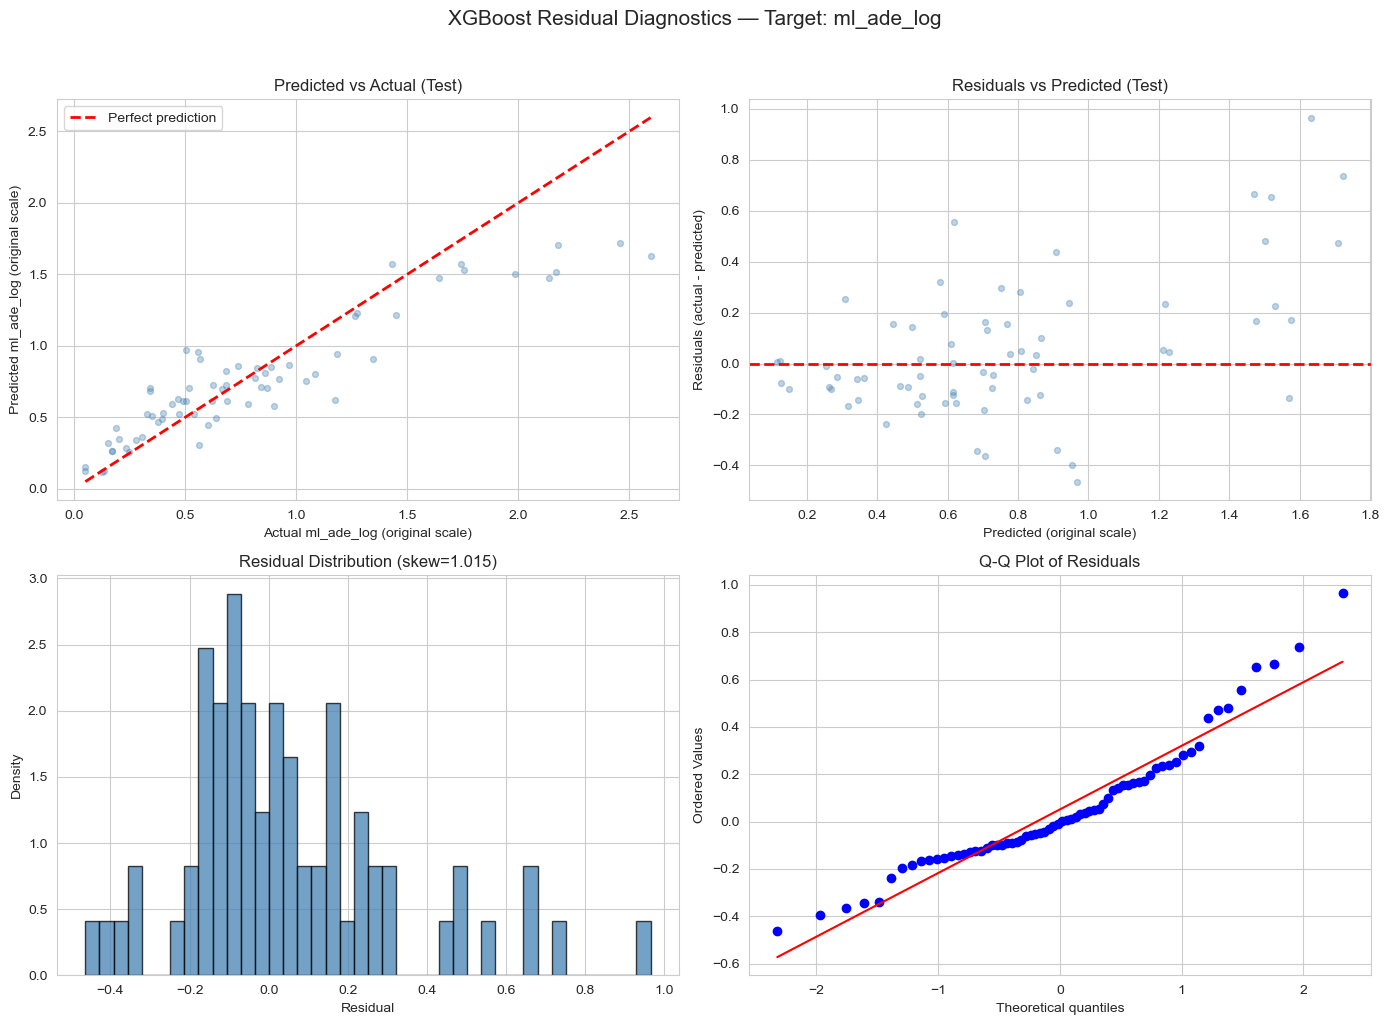

Diagnostics plot saved to: ../../results/interpretable_model/xgboost/plots/residual_diagnostics_ml_ade_log.png
Residual mean:   0.051167
Residual median: -0.003304
Residual std:    0.271603


In [ ]:
residuals_oof = y_oof_orig - y_oof_pred_orig

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Predicted vs actual
axes[0, 0].scatter(y_oof_orig, y_oof_pred_orig, alpha=0.35, s=18, color='steelblue')
lims = [
    min(np.min(y_oof_orig), np.min(y_oof_pred_orig)),
    max(np.max(y_oof_orig), np.max(y_oof_pred_orig)),
]
axes[0, 0].plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
axes[0, 0].set_xlabel(f'Actual {target_col} (original scale)')
axes[0, 0].set_ylabel(f'Predicted {target_col} (original scale)')
axes[0, 0].set_title('Predicted vs Actual (OOF)')
axes[0, 0].legend()

# 2) Residuals vs predicted
axes[0, 1].scatter(y_oof_pred_orig, residuals_oof, alpha=0.35, s=18, color='steelblue')
axes[0, 1].axhline(0.0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted (original scale)')
axes[0, 1].set_ylabel('Residuals (actual - predicted)')
axes[0, 1].set_title('Residuals vs Predicted (OOF)')

# 3) Residual histogram
axes[1, 0].hist(residuals_oof, bins=40, density=True, alpha=0.75, color='steelblue', edgecolor='black')
axes[1, 0].set_xlabel('Residual')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title(f'Residual Distribution (skew={stats.skew(residuals_oof):.3f})')

# 4) Q-Q plot
stats.probplot(residuals_oof, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals')

plt.suptitle(f'XGBoost Residual Diagnostics — Target: {target_col}', fontsize=15, y=1.02)
plt.tight_layout()
diag_path = PLOTS_DIR / f'residual_diagnostics_oof_{target_col}.png'
plt.savefig(diag_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Diagnostics plot saved to: {diag_path}')
print(f'Residual mean:   {residuals_oof.mean():.6f}')
print(f'Residual median: {np.median(residuals_oof):.6f}')
print(f'Residual std:    {residuals_oof.std():.6f}')


## 8. SHAP Interpretability (Global + Local)

,feature,mean_abs_shap
0,max_speed,0.065599
1,std_speed,0.052405
2,path_efficiency,0.034942
3,heading_change,0.022721
4,scene_spatial_density,0.022278
5,max_acceleration,0.020276
6,scene_bbox_area,0.014960
7,mean_acceleration,0.013689
8,scene_density_VEHICLE,0.013013
9,min_neighbor_distance,0.012942


SHAP importance table saved to: ../../results/interpretable_model/xgboost/tables/shap_importance_ml_ade_log.csv
Top 6 features by mean |SHAP|:
['max_speed', 'std_speed', 'path_efficiency', 'heading_change', 'scene_spatial_density', 'max_acceleration']


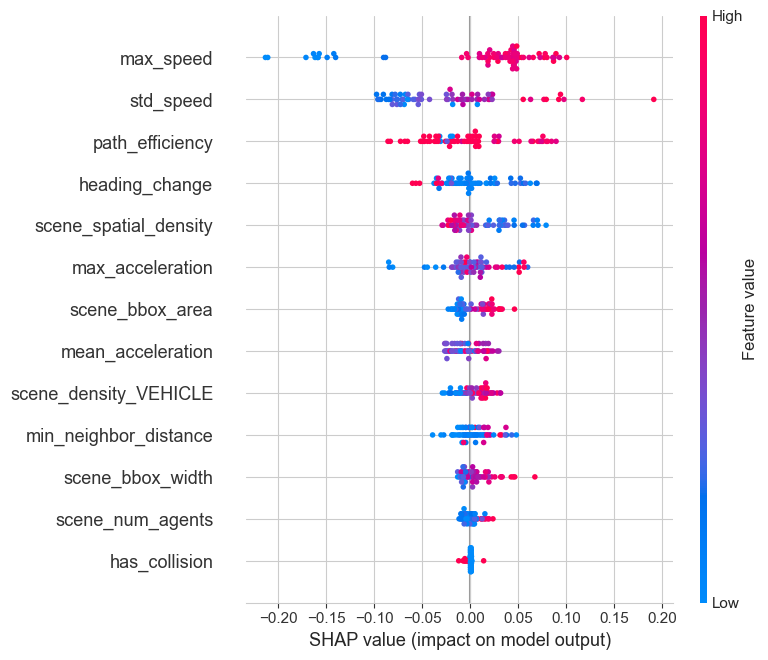

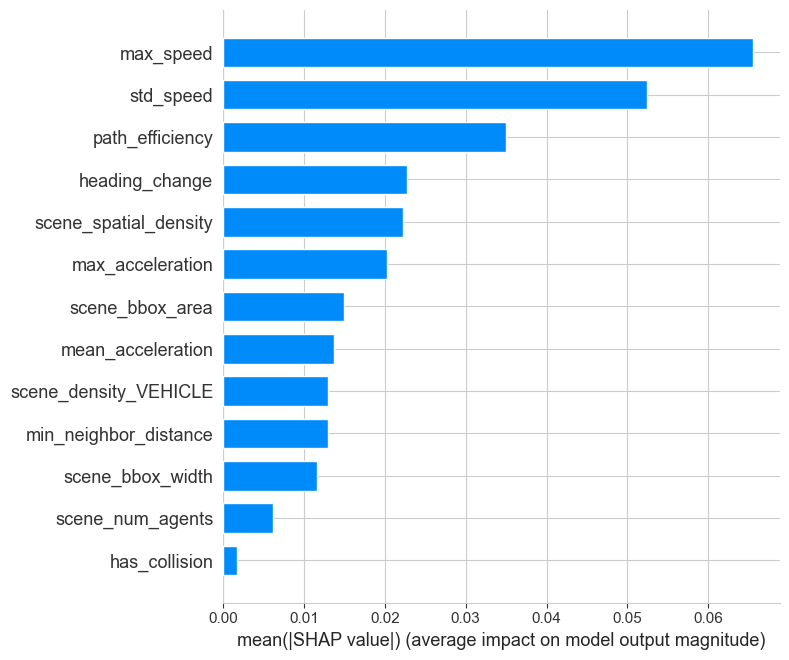

SHAP beeswarm saved to: ../../results/interpretable_model/xgboost/plots/shap_beeswarm_ml_ade_log.png
SHAP bar saved to:      ../../results/interpretable_model/xgboost/plots/shap_bar_ml_ade_log.png


In [ ]:
# Build SHAP explanation on full data (final model)
explainer = shap.Explainer(model, X)
shap_exp = explainer(X)
shap_values = shap_exp.values

# Global importance (mean absolute SHAP)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'feature': X.columns,
    'mean_abs_shap': mean_abs_shap,
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

display(shap_importance_df)

shap_imp_path = TABLES_DIR / f'shap_importance_{target_col}.csv'
shap_importance_df.to_csv(shap_imp_path, index=False)
print(f'SHAP importance table saved to: {shap_imp_path}')

# Keep top features for downstream PDP section
top_features = shap_importance_df['feature'].head(6).tolist()
print('Top 6 features by mean |SHAP|:')
print(top_features)

# SHAP beeswarm
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, show=False, max_display=20)
beeswarm_path = PLOTS_DIR / f'shap_beeswarm_{target_col}.png'
plt.tight_layout()
plt.savefig(beeswarm_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# SHAP bar
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, plot_type='bar', show=False, max_display=20)
bar_path = PLOTS_DIR / f'shap_bar_{target_col}.png'
plt.tight_layout()
plt.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print(f'SHAP beeswarm saved to: {beeswarm_path}')
print(f'SHAP bar saved to:      {bar_path}')


## 9. Partial Dependence Plots (Top 6 SHAP Features)

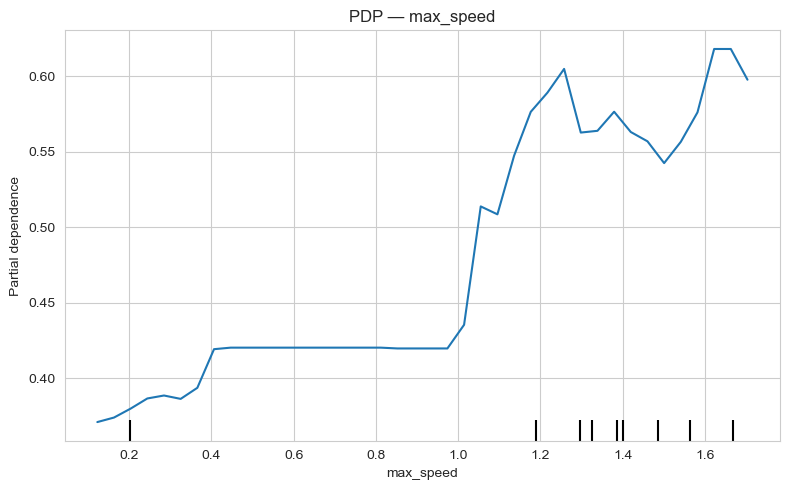

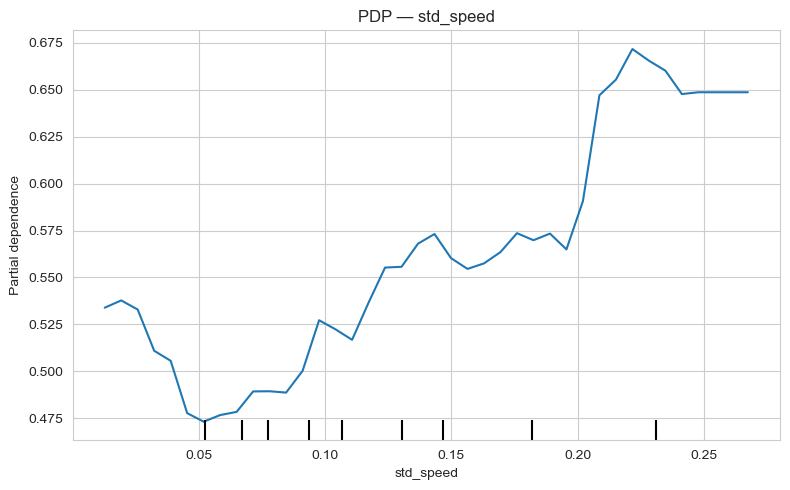

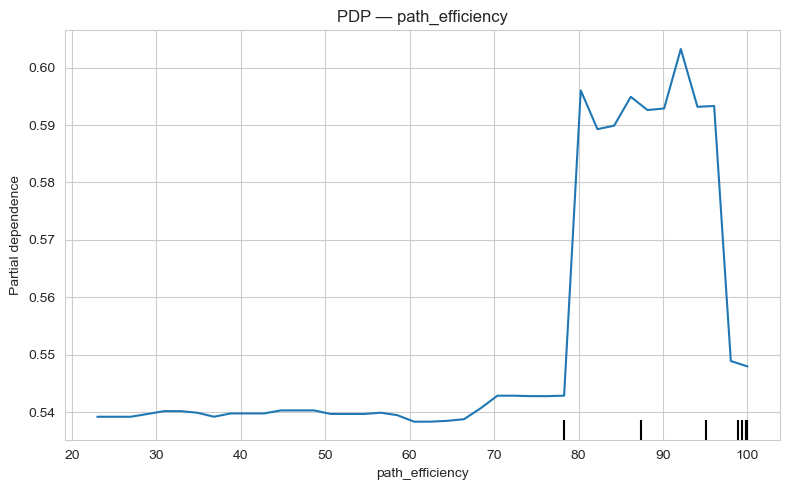

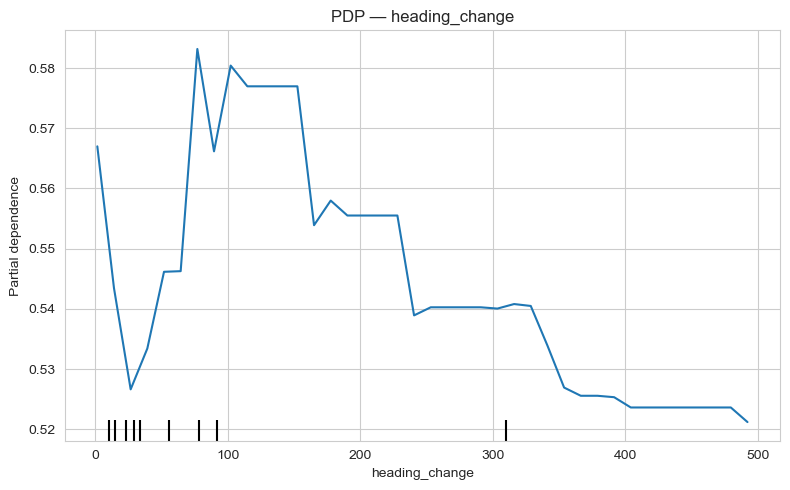

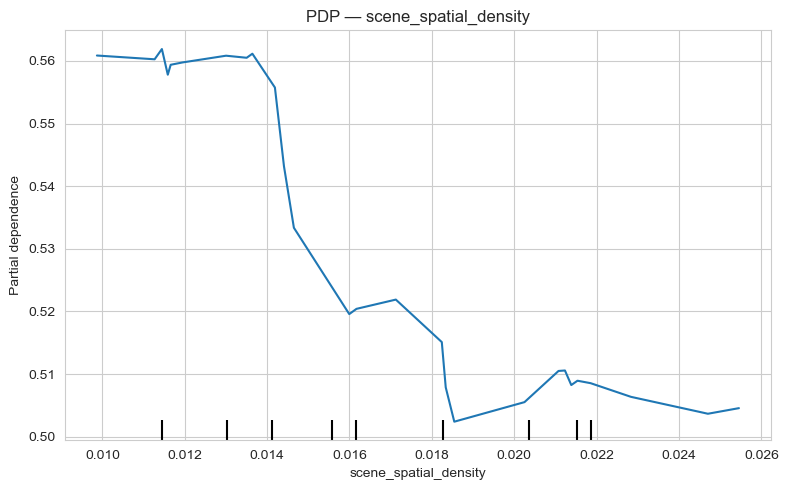

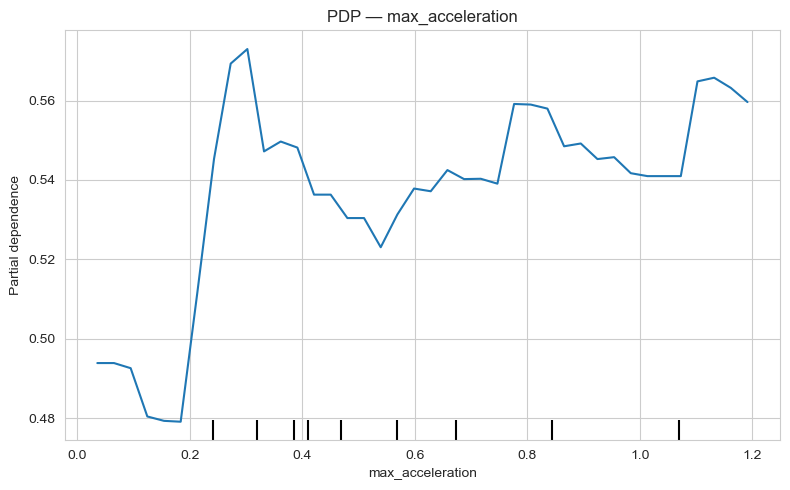

PDP plots saved for top 6 SHAP-ranked features.


In [ ]:
for feat in top_features:
    fig, ax = plt.subplots(figsize=(8, 5))
    PartialDependenceDisplay.from_estimator(
        model,
        X,
        features=[feat],
        kind='average',
        grid_resolution=40,
        ax=ax,
    )
    ax.set_title(f'PDP — {feat}')
    pdp_path = PLOTS_DIR / f'pdp_{feat}_{target_col}.png'
    plt.tight_layout()
    plt.savefig(pdp_path, dpi=150, bbox_inches='tight')
    plt.show()

print('PDP plots saved for top 6 SHAP-ranked features.')


## 10. Cohort Analysis: Poor vs Well Performance (OOF)


In [ ]:
abs_error_oof = np.abs(y_oof_orig - y_oof_pred_orig)
poor_threshold = np.quantile(abs_error_oof, 1.0 - POOR_WELL_QUANTILE)
well_threshold = np.quantile(abs_error_oof, POOR_WELL_QUANTILE)

poor_mask = abs_error_oof >= poor_threshold
well_mask = abs_error_oof <= well_threshold

X_reset = X.reset_index(drop=True).copy()
X_reset['abs_error'] = abs_error_oof

poor_df = X_reset.loc[poor_mask].copy()
well_df = X_reset.loc[well_mask].copy()

print(f'Poor threshold (top {POOR_WELL_QUANTILE:.0%}): abs_error >= {poor_threshold:.6f}')
print(f'Well threshold (bottom {POOR_WELL_QUANTILE:.0%}): abs_error <= {well_threshold:.6f}')
print(f'Poor cohort size: {len(poor_df)}')
print(f'Well cohort size: {len(well_df)}')


Poor threshold (top 20%): abs_error >= 0.309517
Well threshold (bottom 20%): abs_error <= 0.052937
Poor cohort size: 14
Well cohort size: 14


In [ ]:
def standardized_difference(a, b, eps=1e-12):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    pooled = np.sqrt((np.var(a, ddof=1) + np.var(b, ddof=1)) / 2.0)
    if not np.isfinite(pooled) or pooled < eps:
        return 0.0
    return (np.mean(a) - np.mean(b)) / pooled

cohort_rows = []
for feat in feature_cols:
    poor_vals = poor_df[feat].dropna().values
    well_vals = well_df[feat].dropna().values

    cohort_rows.append({
        'feature': feat,
        'poor_mean': np.mean(poor_vals),
        'well_mean': np.mean(well_vals),
        'poor_median': np.median(poor_vals),
        'well_median': np.median(well_vals),
        'mean_diff': np.mean(poor_vals) - np.mean(well_vals),
        'median_diff': np.median(poor_vals) - np.median(well_vals),
        'standardized_diff': standardized_difference(poor_vals, well_vals),
    })

cohort_df = pd.DataFrame(cohort_rows)
cohort_df['abs_standardized_diff'] = cohort_df['standardized_diff'].abs()
cohort_df = cohort_df.sort_values('abs_standardized_diff', ascending=False).reset_index(drop=True)

display(cohort_df)

cohort_path = TABLES_DIR / f'cohort_comparison_{target_col}.csv'
cohort_df.to_csv(cohort_path, index=False)
print(f'Cohort comparison table saved to: {cohort_path}')

,feature,poor_mean,well_mean,poor_median,well_median,mean_diff,median_diff,standardized_diff,abs_standardized_diff
0,mean_acceleration,0.046024,-0.006505,0.049943,-0.004538,0.052529,0.054481,1.546915,1.546915
1,std_speed,0.168883,0.108834,0.160308,0.085966,0.060050,0.074342,0.996571,0.996571
2,min_neighbor_distance,1.468595,3.542648,1.110967,2.616140,-2.074053,-1.505174,-0.961627,0.961627
3,scene_spatial_density,0.014389,0.017863,0.013916,0.018441,-0.003474,-0.004524,-0.907976,0.907976
4,max_speed,1.403941,1.099231,1.391986,1.382789,0.304710,0.009196,0.705698,0.705698
5,max_acceleration,0.654088,0.492033,0.598604,0.444695,0.162055,0.153909,0.663897,0.663897
6,scene_num_agents,19.071429,23.857143,19.000000,19.000000,-4.785714,0.000000,-0.656739,0.656739
7,heading_change,63.043870,210.008027,72.670197,32.650158,-146.964157,40.020039,-0.591601,0.591601
8,path_efficiency,93.089234,78.319042,93.240837,99.113669,14.770191,-5.872832,0.575675,0.575675
9,scene_bbox_width,43.078372,41.810652,43.698157,42.991166,1.267720,0.706991,0.220100,0.220100


Cohort comparison table saved to: ../../results/interpretable_model/xgboost/tables/cohort_comparison_ml_ade_log.csv


Top differentiating features (|standardized_diff|):
['mean_acceleration', 'std_speed', 'min_neighbor_distance', 'scene_spatial_density', 'max_speed', 'max_acceleration']


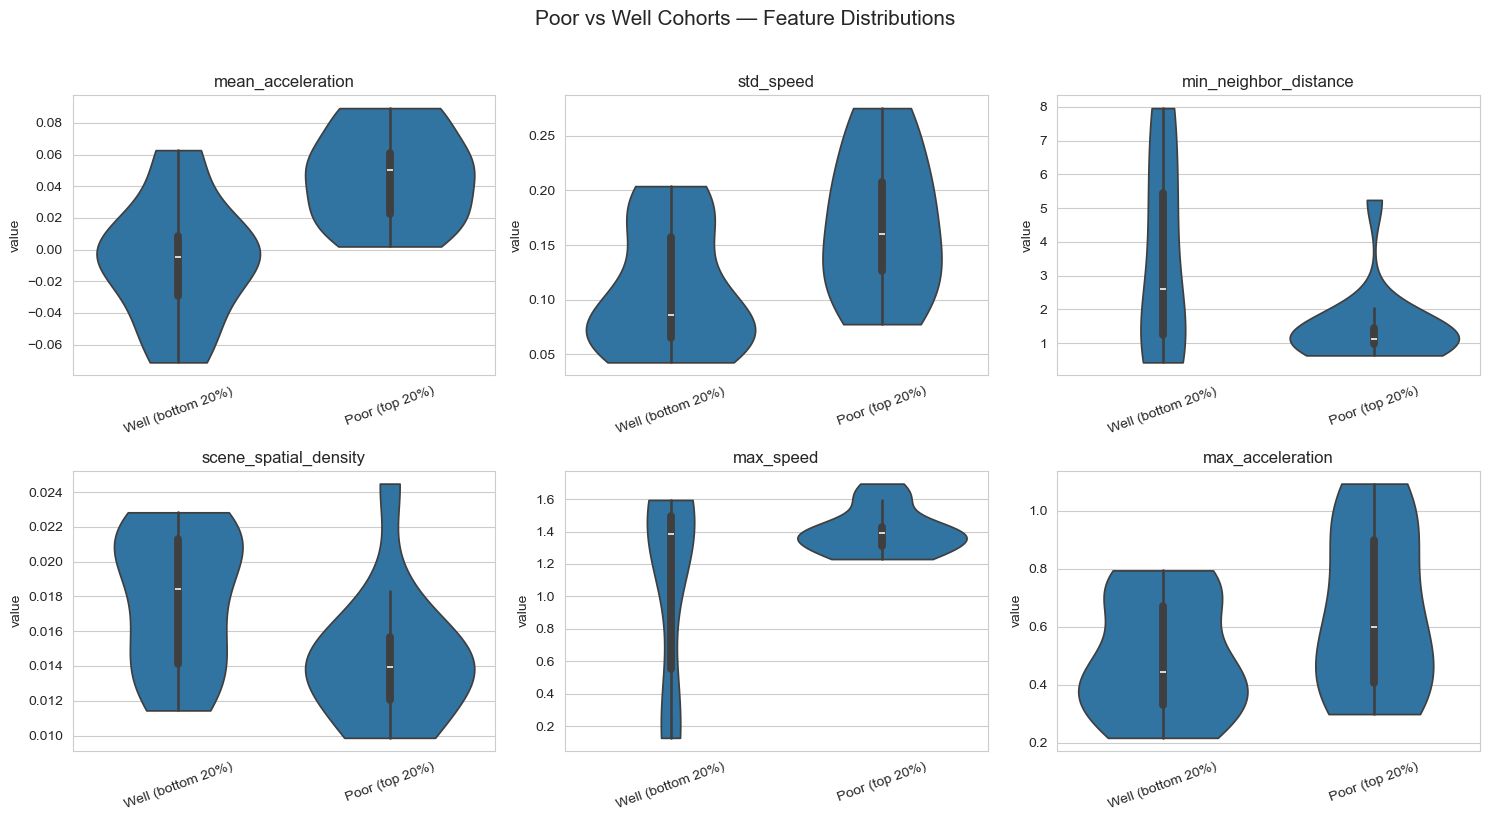

Cohort violin plots saved to: ../../results/interpretable_model/xgboost/plots/cohort_violin_top_features_ml_ade_log.png


In [ ]:
# Violin plots for top differentiating features
top_diff_features = cohort_df['feature'].head(6).tolist()
print('Top differentiating features (|standardized_diff|):')
print(top_diff_features)

n_plot = len(top_diff_features)
n_cols = 3
n_rows = int(np.ceil(n_plot / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, feat in enumerate(top_diff_features):
    long_df = pd.concat([
        pd.DataFrame({'cohort': 'Well (bottom 20%)', 'value': well_df[feat].values}),
        pd.DataFrame({'cohort': 'Poor (top 20%)', 'value': poor_df[feat].values}),
    ], ignore_index=True)

    sns.violinplot(data=long_df, x='cohort', y='value', ax=axes[i], inner='box', cut=0)
    axes[i].set_title(feat)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=20)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Poor vs Well Cohorts — Feature Distributions', fontsize=15, y=1.02)
plt.tight_layout()
cohort_plot_path = PLOTS_DIR / f'cohort_violin_top_features_{target_col}.png'
plt.savefig(cohort_plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Cohort violin plots saved to: {cohort_plot_path}')

## 11. Sanity Checks and Final Summary

In [ ]:
# Sanity check 1: poor median error > well median error
poor_median_error = np.median(abs_error_oof[poor_mask])
well_median_error = np.median(abs_error_oof[well_mask])
print(f'Poor median abs error: {poor_median_error:.6f}')
print(f'Well median abs error: {well_median_error:.6f}')
print(f'Check poor > well: {poor_median_error > well_median_error}')

# Sanity check 2: overlap between top SHAP and top cohort-difference features
top_shap = set(shap_importance_df['feature'].head(6).tolist())
top_cohort = set(cohort_df['feature'].head(6).tolist())
overlap = top_shap.intersection(top_cohort)

print(f'Top SHAP features:   {sorted(top_shap)}')
print(f'Top cohort features: {sorted(top_cohort)}')
print(f'Overlap ({len(overlap)}): {sorted(overlap)}')

print('
Saved artifacts:')
print(f'- Metrics table:          {metrics_path}')
print(f'- SHAP importance table:  {shap_imp_path}')
print(f'- Cohort comparison:      {cohort_path}')
print(f'- Plot directory:         {PLOTS_DIR}')


Poor median abs error: 0.467749
Well median abs error: 0.032788
Check poor > well: True
Top SHAP features:   ['heading_change', 'max_acceleration', 'max_speed', 'path_efficiency', 'scene_spatial_density', 'std_speed']
Top cohort features: ['max_acceleration', 'max_speed', 'mean_acceleration', 'min_neighbor_distance', 'scene_spatial_density', 'std_speed']
Overlap (4): ['max_acceleration', 'max_speed', 'scene_spatial_density', 'std_speed']

Saved artifacts:
- Metrics table:          ../../results/interpretable_model/xgboost/tables/metrics_ml_ade_log.csv
- SHAP importance table:  ../../results/interpretable_model/xgboost/tables/shap_importance_ml_ade_log.csv
- Cohort comparison:      ../../results/interpretable_model/xgboost/tables/cohort_comparison_ml_ade_log.csv
- Plot directory:         ../../results/interpretable_model/xgboost/plots
